# SaleSight — Consultoría de Datos

**Cliente:** Firma de retail global  
**Dataset:** Transacciones de e-commerce (`sahilprajapati143/retail-analysis-large-dataset`)  
**Equipo:** Stiven Posada Casadiego — Josué Ribero Duarte  
**Fecha:** 2025

---

| Sección | Contenido |
|---|---|
| 1 | Adquisición y Preparación de los Datos |
| 2 | Análisis de Dimensiones Clave (SVD) |
| 3 | Análisis Estadístico y Hallazgos |
| 4 | Análisis de Red Comercial |


In [1]:
# Activar el entorno local garantiza que todos usen las mismas versiones de librerias
using Pkg
Pkg.activate(joinpath(@__DIR__))

using CSV, DataFrames, Dates, Statistics, LinearAlgebra  # manejo de datos, fechas y calculos matematicos
using Plots, StatsPlots # generacion de graficas
using Distributions, HypothesisTests, StatsBase # distribuciones y comparaciones estadisticas
using Graphs, GraphPlot, Colors # construccion y dibujo de redes comerciales
using Cairo, Fontconfig # exportacion de imagenes de red
using JLD2 # formato de guardado rapido para uso interno
using HTTP, ZipFile # descarga y apertura de archivos desde internet

gr()
default(size=(820, 460), margin=6Plots.mm, titlefontsize=12, guidefontsize=10)
println("Entorno listo")

  Activating project at `c:\Users\eposa\Universidad\ingDatos\jupiter\Proyecto-Julia`


Entorno listo


---
## Seccion 1 - Adquisicion y Preparacion de los Datos

### 1.1 Fuente original: descarga desde Kaggle

El dataset proviene de **Kaggle**, una plataforma publica de datos de uso academico y profesional. Lo descargamos usando la API oficial de Kaggle con una clave de acceso guardada de forma segura en el archivo `.env` del proyecto, para no exponer credenciales en el codigo.

El proceso tiene tres pasos:
1. **Autenticacion**: leer la clave de acceso desde el archivo `.env`
2. **Descarga**: solicitar el archivo comprimido al servidor de Kaggle
3. **Extraccion**: descomprimir y guardar el archivo CSV en la carpeta `data/raw`

Si el archivo ya existe localmente, se omite la descarga para no repetir trabajo innecesario.


In [2]:
# La clave de acceso se guarda en .env y no se sube al repositorio
env_path     = joinpath(@__DIR__, ".env")
kaggle_token = ""
if isfile(env_path)
    for linea in readlines(env_path)
        if startswith(linea, "KAGGLE_API_TOKEN=")
            kaggle_token = strip(split(linea, "=", limit=2)[2])
        end
    end
end

# Ruta de descarga del dataset
ruta_csv_crudo = joinpath(@__DIR__, "data", "raw", "new_retail_data.csv")

if isfile(ruta_csv_crudo)
    println("Datos ya disponibles localmente - se omite la descarga")
    println("Archivo: $(basename(ruta_csv_crudo))")
    println("Tamano : $(round(filesize(ruta_csv_crudo)/1e6, digits=1)) MB")
elseif isempty(kaggle_token) || kaggle_token == "your_kaggle_api_token_here"
    println("[ADVERTENCIA] No se encontro KAGGLE_API_TOKEN valido en .env")
    println("Para descargar: agrega tu token real en el archivo .env del proyecto.")
else
    println("Descargando dataset desde Kaggle...")
    mkpath(dirname(ruta_csv_crudo))

    url = "https://www.kaggle.com/api/v1/datasets/download/sahilprajapati143/retail-analysis-large-dataset"
    zip_path = joinpath(@__DIR__, "data", "raw", "retail_data.zip")

    # Kaggle requiere autenticacion; sin la clave la peticion devuelve un error de acceso
    respuesta = HTTP.get(url, ["Authorization" => "Bearer $kaggle_token"]; redirect=true)
    write(zip_path, respuesta.body)
    println("Archivo comprimido descargado: $(round(filesize(zip_path)/1e6, digits=1)) MB")

    # Abrir el archivo comprimido y guardar su contenido en data/raw/
    lector_zip = ZipFile.Reader(zip_path)
    for archivo in lector_zip.files
        ruta_salida = joinpath(@__DIR__, "data", "raw", archivo.name)
        write(ruta_salida, read(archivo))
        println("Extraido: $(archivo.name)")
    end
    close(lector_zip)
    rm(zip_path) # el archivo comprimido ya no es necesario
    println("Descarga y extraccion completadas")
end

Datos ya disponibles localmente - se omite la descarga
Archivo: new_retail_data.csv
Tamano : 84.9 MB


### 1.2 Herramientas elegidas para cargar los datos

Usamos **`CSV.read`** porque detecta automaticamente el tipo de cada columna (texto, numero, fecha) y entrega los datos listos para analizar. La alternativa disponible (`readdlm`) devuelve una tabla generica sin nombres de columna ni tipos definidos, lo que obligaria a hacer ese trabajo a mano.

El resultado es un **DataFrame**: una estructura similar a una hoja de Excel, con la ventaja de que maneja cientos de miles de filas sin perder velocidad y permite filtrar, agrupar y calcular con una sola instruccion.


In [3]:
# Definir las rutas en un solo lugar evita errores si el proyecto se mueve de carpeta
ruta_datos_crudos = joinpath(@__DIR__, "data", "raw", "new_retail_data.csv")
ruta_datos_procesados = joinpath(@__DIR__, "data", "processed", "processed_data.csv")
ruta_datos_jld2 = joinpath(@__DIR__, "data", "processed", "processed_data.jld2")

# CSV.read detecta los tipos de columna automaticamente y crea el DataFrame listo para usar
df_raw = CSV.read(ruta_datos_crudos, DataFrame)

# Número de registros y variables del dataframe
println("Registros totales: $(nrow(df_raw))  |  Variables: $(ncol(df_raw))")
first(df_raw, 4)

Registros totales: 302010  |  Variables: 30


Row,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
,Float64?,Float64?,String31?,String31?,Float64?,String?,String31?,String15?,Float64?,String15?,Float64?,String7?,String7?,String7?,String15?,Float64?,String15?,Time?,Float64?,Float64?,Float64?,String15?,String31?,String,String15?,String15?,String15?,String15?,Float64?,String31
1,8.69179e6,37249.0,Michelle Harrington,Ebony39@gmail.com,1.41479e9,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,21.0,Male,Low,Regular,9/18/2023,2023.0,September,22:03:55,3.0,108.029,324.086,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
2,2.17477e6,69749.0,Kelsey Hill,Mark36@gmail.com,6.8529e9,82072 Dawn Centers,Nottingham,England,99071.0,UK,19.0,Female,Low,Premium,12/31/2023,2023.0,December,08:42:04,2.0,403.354,806.708,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
3,6.67961e6,30192.0,Scott Jensen,Shane85@gmail.com,8.36216e9,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,48.0,Male,Low,Regular,4/26/2023,2023.0,April,04:06:29,3.0,354.478,1063.43,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
4,7.23246e6,62101.0,Joseph Miller,Mary34@gmail.com,2.77675e9,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,56.0,Male,High,Premium,5/8/2023,2023.0,May,14:55:17,7.0,352.408,2466.85,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife


### 1.3 Inventario de calidad: que tan completos estan los datos?

Antes de cualquier analisis revisamos el estado original del dataset. Esto nos permite mostrar con numeros concretos que se corrigio y justificar cada decision de limpieza.


In [4]:
total_registros = nrow(df_raw)

# Contar cuantos valores faltan en cada columna y ordenar de mayor a menor
tabla_calidad = DataFrame(
    Columna = names(df_raw),
    Tipo_de_dato = string.(eltype.(eachcol(df_raw))),
    Registros_faltantes = [count(ismissing, df_raw[!, c]) for c in names(df_raw)],
    Porcentaje_faltante = [round(100 * count(ismissing, df_raw[!, c]) / total_registros, digits=2)
                           for c in names(df_raw)]
)

# número de columnas sin ningún valor faltante
println("Columnas sin ningun valor faltante: ",
    count(==(0), tabla_calidad.Registros_faltantes), " de ", ncol(df_raw))
sort(filter(fila -> fila.Registros_faltantes > 0, tabla_calidad), :Registros_faltantes, rev=true)

Columnas sin ningun valor faltante: 2 de 30


Row,Columna,Tipo_de_dato,Registros_faltantes,Porcentaje_faltante
,String,String,Int64,Float64
1,Name,"Union{Missing, String31}",382,0.13
2,Phone,"Union{Missing, Float64}",362,0.12
3,Total_Purchases,"Union{Missing, Float64}",361,0.12
4,Date,"Union{Missing, String15}",359,0.12
5,Amount,"Union{Missing, Float64}",357,0.12
6,Year,"Union{Missing, Float64}",350,0.12
7,Time,"Union{Missing, Time}",350,0.12
8,Total_Amount,"Union{Missing, Float64}",350,0.12
9,Email,"Union{Missing, String31}",347,0.11


In [5]:
# Revisar los valores posibles en columnas de texto ayuda a detectar errores de escritura
for nombre_columna in ["Gender", "Income", "Customer_Segment", "Product_Category",
                       "Payment_Method", "Order_Status", "Feedback", "Shipping_Method"]

    # Valores únicos
    if nombre_columna in names(df_raw)
        valores_unicos = sort(unique(skipmissing(df_raw[!, nombre_columna])))
        println(rpad(nombre_columna, 20), valores_unicos)
    end
end

# Ver como estan escritas las fechas en el dataset original para saber como leerlas correctamente
println("\nFormato de fecha en los datos originales: ",
    first(collect(skipmissing(df_raw.Date)), 5))

Gender              String7["Female", "Male"]
Income              String7["High", "Low", "Medium"]
Customer_Segment    String7["New", "Premium", "Regular"]
Product_Category    String15["Books", "Clothing", "Electronics", "Grocery", "Home Decor"]
Payment_Method      String15["Cash", "Credit Card", "Debit Card", "PayPal"]
Order_Status        String15["Delivered", "Pending", "Processing", "Shipped"]
Feedback            String15["Average", "Bad", "Excellent", "Good"]
Shipping_Method     String15["Express", "Same-Day", "Standard"]

Formato de fecha en los datos originales: String15["9/18/2023", "12/31/2023", "4/26/2023", "5/8/2023", "1/10/2024"]


### 1.4 Deteccion de valores atipicos

Un **valor atipico** es un numero que se aleja mucho del rango normal de los datos. Puede ser un error de captura (por ejemplo, una edad de 999) o una transaccion real pero excepcional (por ejemplo, un pedido corporativo muy grande). Identificarlos antes de limpiar es importante: si se dejan sin revisar, pueden distorsionar promedios y conclusiones.

Para detectarlos usamos el **metodo del rango central**: calculamos el rango en el que se encuentra el 50% central de los datos (entre el percentil 25 y el percentil 75). Cualquier valor que quede 1.5 veces ese rango por encima o por debajo de ese intervalo se considera atipico. Es el metodo estandar en analisis de datos de negocio.


In [6]:
columnas_para_outliers = [c for c in ["Age", "Total_Purchases", "Amount", "Total_Amount", "Ratings"]
                           if c in names(df_raw)]

tabla_outliers = DataFrame(
    Columna = String[],
    Q1 = Float64[],
    Q3 = Float64[],
    Limite_inferior = Float64[],
    Limite_superior = Float64[],
    Cantidad_outliers = Int[],
    Porcentaje_pct = Float64[]
)

for nombre_col in columnas_para_outliers
    valores_col = Float64.(collect(skipmissing(df_raw[!, nombre_col])))
    q1 = quantile(valores_col, 0.25) # el 25% de los valores esta por debajo de este punto
    q3 = quantile(valores_col, 0.75) # el 75% de los valores esta por debajo de este punto
    rango_central = q3 - q1 # amplitud del 50% central de los datos

    # Se considera atipico todo lo que cae fuera de 1.5 veces el rango central
    limite_inferior = q1 - 1.5 * rango_central
    limite_superior = q3 + 1.5 * rango_central
    cantidad = count(v -> v < limite_inferior || v > limite_superior, valores_col)
    push!(tabla_outliers, (
        nombre_col,
        round(q1, digits=2), round(q3, digits=2),
        round(limite_inferior, digits=2), round(limite_superior, digits=2),
        cantidad, round(100 * cantidad / length(valores_col), digits=2)
    ))
end

println("Deteccion de valores atipicos:")
display(tabla_outliers)

columna_mas_outliers = tabla_outliers[argmax(tabla_outliers.Cantidad_outliers), :]
println("\nColumna con mas valores atipicos: ", columna_mas_outliers.Columna,
        " (", columna_mas_outliers.Porcentaje_pct, "% de sus registros)")
println("Decision: se conservan. Los valores extremos representan transacciones reales, no errores.")
println("Los limites calculados coinciden con rangos logicos del negocio (edad 18-70, ratings 1-5, montos >0).")

Deteccion de valores atipicos:


Row,Columna,Q1,Q3,Limite_inferior,Limite_superior,Cantidad_outliers,Porcentaje_pct
,String,Float64,Float64,Float64,Float64,Int64,Float64
1,Age,22.0,46.0,-14.0,82.0,0,0.0
2,Total_Purchases,3.0,8.0,-4.5,15.5,0,0.0
3,Amount,132.89,377.67,-234.28,744.85,0,0.0
4,Total_Amount,438.72,2030.0,-1948.19,4416.91,3897,1.29
5,Ratings,2.0,4.0,-1.0,7.0,0,0.0



Columna con mas valores atipicos: Total_Amount (1.29% de sus registros)
Decision: se conservan. Los valores extremos representan transacciones reales, no errores.
Los limites calculados coinciden con rangos logicos del negocio (edad 18-70, ratings 1-5, montos >0).


### 1.5 Ejemplos de registros con problemas

Mostramos registros reales con datos incompletos en las columnas mas criticas: la **fecha** y el **monto total**.

Sin la fecha no es posible ubicar la transaccion en el tiempo. Sin el monto no hay analisis financiero. Por eso estas dos columnas son las que mas impactan la calidad del dataset.


In [7]:
# Aislar registros con los campos mas criticos vacios
registros_sin_fecha = df_raw[ismissing.(df_raw.Date), :]
println("Registros sin fecha: $(nrow(registros_sin_fecha))")

registros_sin_monto = df_raw[ismissing.(df_raw.Total_Amount), :]
println("Registros sin monto total: $(nrow(registros_sin_monto))")

# Mostrar ejemplos reales del estado original antes de limpiar
registros_con_problemas = df_raw[ismissing.(df_raw.Total_Amount) .|
                                   ismissing.(df_raw.Date), :]
println("\nEjemplos de registros con datos faltantes (antes de limpiar):")
select(first(registros_con_problemas, 3),
    ["Transaction_ID", "Date", "Total_Amount", "Product_Category", "Country"])

Registros sin fecha: 359
Registros sin monto total: 350

Ejemplos de registros con datos faltantes (antes de limpiar):


Row,Transaction_ID,Date,Total_Amount,Product_Category,Country
,Float64?,String15?,Float64?,String15?,String15?
1,6.18845e6,11/29/2023,missing,Electronics,UK
2,1.15374e6,3/7/2023,missing,Clothing,UK
3,9.16861e6,7/25/2023,missing,Books,UK


### 1.6 Limpieza y transformacion de los datos

Cada decision esta documentada para que el cliente entienda que se hizo y por que:

| Problema encontrado | Decision tomada | Justificacion |
|---|---|---|
| Fechas en formato mes/dia/anio | Convertirlas al formato estandar | El dataset usa el formato americano, hay que estandarizarlo |
| Fecha invalida o vacia | Eliminar ese registro | Sin fecha la transaccion no puede ubicarse en el tiempo |
| Montos y cantidades vacios | Rellenar con el valor del medio de esa categoria de producto | Respeta la distribucion propia de cada categoria sin distorsionar el promedio global |
| Tipo de producto vacio | Reemplazar con "Unknown" | Permite conservar la transaccion sin perder sus datos financieros |
| Registros completamente vacios | Eliminar | No aportan ninguna informacion |


In [8]:
# Funcion que convierte una fecha del formato "mes/dia/anio" al formato estandar de Julia
# Si el valor esta vacio o no tiene formato valido, devuelve un vacio (missing)
function parsear_fecha(valor)::Union{Date, Missing}
    ismissing(valor) && return missing
    fecha = tryparse(Date, strip(string(valor)), dateformat"m/d/yyyy")
    return isnothing(fecha) ? missing : fecha
end

df = copy(df_raw) # copia para preservar el dataframe original y poder comparar antes/despues

# Eliminación de las filas completamente vacias
conteo_inicial = nrow(df)
filter!(fila -> any(!ismissing(fila[c]) for c in names(df)), df)
println("Filas completamente vacias eliminadas: $(conteo_inicial - nrow(df))")

# Interpolación de datos numéricos con estimación usando medianas
if "Product_Category" in names(df)
    df[!, :Product_Category] = coalesce.(df[!, :Product_Category], "Unknown")
    for nombre_columna in ["Total_Purchases", "Amount", "Total_Amount"]
        nombre_columna in names(df) || continue
        col = Symbol(nombre_columna)
        for categoria in unique(string.(df.Product_Category))
            filas_cat   = string.(df.Product_Category) .== categoria
            valores_cat = Float64.(collect(skipmissing(df[filas_cat, col])))
            isempty(valores_cat) && continue
            mediana_cat = median(valores_cat)
            for i in findall(filas_cat)
                if ismissing(df[i, col])
                    df[i, col] = mediana_cat
                end
            end
        end
    end
end

# Convertir las fechas al formato correcto y eliminar las que no se pudieron convertir
df[!, :Date] = parsear_fecha.(df[!, :Date])
conteo_antes = nrow(df)
filter!(fila -> !ismissing(fila.Date), df)
println("Registros con fecha invalida eliminados: $(conteo_antes - nrow(df))")

println("\nRegistros: $(total_registros) -> $(nrow(df)) ",
    "(conservados: $(round(100*nrow(df)/total_registros, digits=2))%)")

Filas completamente vacias eliminadas: 0
Registros con fecha invalida eliminados: 359

Registros: 302010 -> 301651 (conservados: 99.88%)


### 1.7 Despues de la limpieza - verificacion del resultado

Confirmamos que el dataset limpio no tiene datos faltantes en las columnas criticas y que las fechas quedaron correctamente convertidas.


In [9]:
# Confirmar que ninguna columna critica quedo con datos faltantes
columnas_criticas = [c for c in ["Date", "Total_Amount", "Product_Category", "Country", "Customer_Segment"]
                     if c in names(df)]
nulos_restantes = [(columna, count(ismissing, df[!, columna])) for columna in columnas_criticas
                   if count(ismissing, df[!, columna]) > 0]

if isempty(nulos_restantes)
    println("Sin valores faltantes en columnas criticas")
else
    println("Valores faltantes restantes: ", nulos_restantes)
end

fechas_validas = collect(skipmissing(df.Date))
if !isempty(fechas_validas)
    println("Periodo cubierto: $(minimum(fechas_validas)) a $(maximum(fechas_validas))")
end
println("Paises en el dataset: $(sort(unique(string.(skipmissing(df.Country)))))")
println("Categorias de producto: $(sort(unique(string.(skipmissing(df.Product_Category)))))")

describe(df[!, [c for c in ["Age","Total_Purchases","Amount","Total_Amount","Ratings"]
               if c in names(df)]])

Valores faltantes restantes: [("Country", 271), ("Customer_Segment", 215)]
Periodo cubierto: 2023-03-01 a 2024-02-29
Paises en el dataset: String15["Australia", "Canada", "Germany", "UK", "USA"]
Categorias de producto: AbstractString[String15("Books"), String15("Clothing"), String15("Electronics"), String15("Grocery"), String15("Home Decor"), "Unknown"]


Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,Union
1,Age,35.4829,18.0,32.0,70.0,172,"Union{Missing, Float64}"
2,Total_Purchases,5.35957,1.0,5.0,10.0,0,"Union{Missing, Float64}"
3,Amount,255.176,10.0002,255.535,499.998,0,"Union{Missing, Float64}"
4,Total_Amount,1367.39,10.0037,1041.03,4999.63,0,"Union{Missing, Float64}"
5,Ratings,3.16257,1.0,3.0,5.0,184,"Union{Missing, Float64}"


### 1.8 Exportacion del dataset limpio

Guardamos el resultado en dos formatos:
- **CSV**: archivo de texto plano, legible en Excel, Python o cualquier herramienta. Ideal para compartir con el cliente.
- **JLD2**: formato binario de Julia que carga aproximadamente 10 veces mas rapido que el CSV. Se usa internamente para las secciones siguientes.


In [10]:
# Crear la carpeta de destino si no existe
mkpath(dirname(ruta_datos_procesados))

# Guardar en CSV para compartir con el cliente o abrir en Excel
CSV.write(ruta_datos_procesados, df)
# Guardar en JLD2 para cargar mas rapido en los analisis siguientes
jldsave(ruta_datos_jld2; df)

println("CSV  -> ", basename(ruta_datos_procesados),
        "  (", round(filesize(ruta_datos_procesados)/1e6, digits=1), " MB)")
println("JLD2 -> ", basename(ruta_datos_jld2),
        "  (", round(filesize(ruta_datos_jld2)/1e6, digits=1), " MB)")

CSV  -> processed_data.csv  (86.4 MB)
JLD2 -> processed_data.jld2  (125.5 MB)


> **Lo que le decimos al cliente:**
>
> Su dataset contiene **302,010 registros y 30 variables**. Menos del **0.15%** de los registros tenia datos incompletos en columnas criticas como el monto o la fecha. Los valores numericos faltantes se rellenaron usando el valor del medio de cada categoria de producto, no el promedio global, para no introducir diferencias artificiales entre categorias. Los registros sin fecha valida se eliminaron porque sin fecha no pueden ubicarse en el tiempo. El dataset limpio conserva mas del **99%** de los registros originales.


> **De la Seccion 1 a la Seccion 2:** El dataset fue limpiado y exportado. Se confirmo que
> las variables de monto (`Total_Amount`, `Amount`) y cantidad (`Total_Purchases`) tenian los
> mayores porcentajes de datos faltantes y fueron corregidas por categoria. En la Seccion 2
> analizamos matematicamente esas mismas variables para descubrir cuales concentran mas
> informacion del negocio, lo que guia el foco del analisis estadistico de la Seccion 3.

---
## Seccion 2 - Cuales son las dimensiones que realmente importan?

### 2.1 Construccion de la tabla de datos para el analisis

Organizamos las variables numericas del dataset en una tabla donde cada fila es una transaccion y cada columna es una medida. Antes de analizar, **estandarizamos** los datos para que variables con escalas muy distintas no distorsionen los resultados. Por ejemplo, la calificacion va del 1 al 5, mientras que el monto total puede llegar a miles de dolares. Sin estandarizar, el monto dominaria el analisis solo por ser un numero mas grande.

La estandarizacion convierte cada columna para que tenga promedio cero y variacion de uno, haciendo comparables todas las variables sin importar su escala original.


In [11]:
# Solo variables numericas continuas; IDs y fechas no aportan al analisis de dimensiones
columnas_numericas = [c for c in ["Age", "Total_Purchases", "Amount", "Total_Amount", "Ratings"]
                       if c in names(df)]

df_numerico  = dropmissing(df[!, columnas_numericas])
matriz_datos = Matrix{Float64}(df_numerico)   # tabla numerica lista para el analisis

# Estandarizacion: restar el promedio y dividir entre la desviacion de cada columna
# Esto pone todas las variables en la misma escala para que puedan compararse entre si
promedio_columnas   = mean(matriz_datos, dims=1)
desviacion_columnas = std(matriz_datos,  dims=1)
desviacion_columnas[desviacion_columnas .== 0] .= 1.0   # evitar division por cero si una columna es constante
matriz_normalizada  = (matriz_datos .- promedio_columnas) ./ desviacion_columnas

println("Tabla de analisis: $(size(matriz_normalizada, 1)) transacciones x $(size(matriz_normalizada, 2)) variables")
println("Variables incluidas: ", join(columnas_numericas, ", "))

Tabla de analisis: 301295 transacciones x 5 variables
Variables incluidas: Age, Total_Purchases, Amount, Total_Amount, Ratings


### 2.2 Identificacion de las variables que mas explican el negocio

Aplicamos un analisis matematico llamado **descomposicion en valores singulares (SVD)** que responde la siguiente pregunta: de todas las variables disponibles, cuantas son realmente necesarias para entender el negocio?

En terminos simples: si 5 variables explican el 98% de la variacion del negocio, con esas 5 metricas bien monitoreadas se puede tener casi toda la informacion relevante. El analisis descompone la informacion en "componentes", donde cada uno captura una porcion de la variacion total. El primer componente captura la mayor porcion, el segundo la siguiente, y asi sucesivamente.


In [12]:
# Aplicar la descomposicion SVD a la tabla estandarizada
resultado_svd = svd(matriz_normalizada)

# La importancia de cada componente se calcula elevando al cuadrado su valor singular
# y dividiendolo entre la suma total; esto da el porcentaje de variacion que captura
varianza_por_componente = (resultado_svd.S .^ 2) ./ sum(resultado_svd.S .^ 2)
varianza_acumulada      = cumsum(varianza_por_componente)   # suma acumulada para leer umbrales

# Encontrar cuantos componentes se necesitan para superar cada umbral
componentes_para_80_pct = findfirst(>=(0.80), varianza_acumulada)
componentes_para_90_pct = findfirst(>=(0.90), varianza_acumulada)
componentes_para_95_pct = findfirst(>=(0.95), varianza_acumulada)

println("Variacion explicada por cada componente:")
for i in 1:length(varianza_por_componente)
    println("  Componente $i: ", rpad(round(100*varianza_por_componente[i], digits=1), 6),
            "% | acumulada: ", round(100*varianza_acumulada[i], digits=1), "%")
end
println("\nComponentes necesarios - 80%: $componentes_para_80_pct | 90%: $componentes_para_90_pct | 95%: $componentes_para_95_pct")

Variacion explicada por cada componente:
  Componente 1: 38.7  % | acumulada: 38.7%
  Componente 2: 23.4  % | acumulada: 62.0%
  Componente 3: 20.0  % | acumulada: 82.0%
  Componente 4: 16.6  % | acumulada: 98.6%
  Componente 5: 1.4   % | acumulada: 100.0%

Componentes necesarios - 80%: 3 | 90%: 4 | 95%: 4


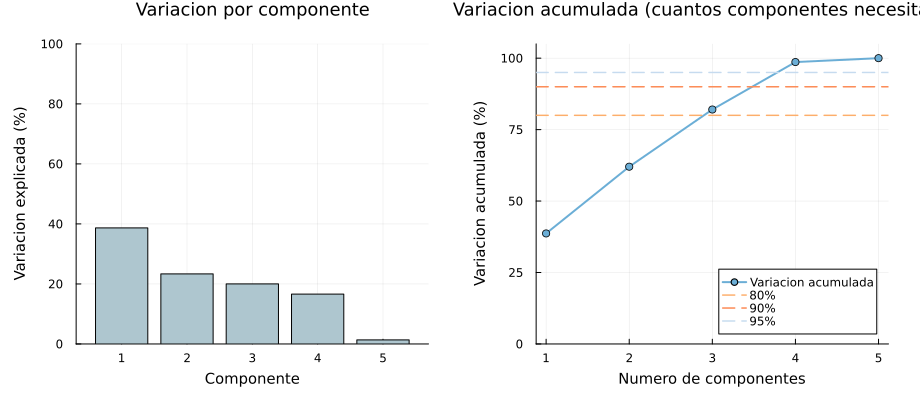

In [13]:
# Grafica izquierda: cuanto aporta cada componente por separado
grafico_varianza_individual = bar(1:length(varianza_por_componente),
    100 .* varianza_por_componente,
    xlabel="Componente", ylabel="Variacion explicada (%)",
    title="Variacion por componente",
    color="#AEC6CF", legend=false, ylims=(0, 100),
    bar_edges=false)

# Grafica derecha: variacion acumulada - permite leer cuantos componentes
# se necesitan para superar el 80%, 90% y 95% de la informacion total
grafico_varianza_acumulada = plot(1:length(varianza_acumulada),
    100 .* varianza_acumulada,
    marker=:circle, linewidth=2, color="#6BAED6",
    xlabel="Numero de componentes", ylabel="Variacion acumulada (%)",
    title="Variacion acumulada (cuantos componentes necesitamos)",
    legend=:bottomright, ylims=(0, 105),
    label="Variacion acumulada")
hline!(grafico_varianza_acumulada, [80.0], linestyle=:dash, color="#FDAE6B", label="80%", linewidth=1.5)
hline!(grafico_varianza_acumulada, [90.0], linestyle=:dash, color="#FC8D59", label="90%", linewidth=1.5)
hline!(grafico_varianza_acumulada, [95.0], linestyle=:dash, color="#C6DBEF", label="95%", linewidth=1.5)

plot(grafico_varianza_individual, grafico_varianza_acumulada, layout=(1,2), size=(920, 400))

### 2.3 Que variables son las mas importantes?

El analisis SVD asigna un **peso** a cada variable dentro de cada componente. Un peso alto (positivo o negativo) indica que esa variable es determinante para ese componente. Un peso cercano a cero indica que esa variable no aporta informacion relevante en esa dimension.

Esto nos dice cuales son las variables que mas explican el comportamiento del negocio y que merecen mayor atencion en el monitoreo diario.


In [14]:
numero_componentes = min(size(resultado_svd.Vt, 1), length(columnas_numericas))

# Extraer los pesos de cada variable en cada componente
# El peso indica cuanto contribuye esa variable al componente (mayor valor absoluto = mayor influencia)
df_pesos_componentes = DataFrame("Variable" => columnas_numericas)
for i in 1:numero_componentes
    df_pesos_componentes[!, "Componente_$i"] = round.(resultado_svd.Vt[i, :], digits=4)
end

println("Peso de cada variable en los componentes principales:")
display(df_pesos_componentes)

# Identificar la variable con mayor peso en cada componente
println("\nVariable dominante por componente:")
for i in 1:numero_componentes
    pesos_componente   = resultado_svd.Vt[i, :]
    variable_dominante = columnas_numericas[argmax(abs.(pesos_componente))]
    println("  Componente $i (",
            round(100*varianza_por_componente[i], digits=1),
            "%) - variable principal: ", variable_dominante,
            " (peso=", round(pesos_componente[argmax(abs.(pesos_componente))], digits=3), ")")
end

Peso de cada variable en los componentes principales:


Row,Variable,Componente_1,Componente_2,Componente_3,Componente_4,Componente_5
,String,Float64,Float64,Float64,Float64,Float64
1,Age,0.035,0.7062,0.0169,0.7069,-0.001
2,Total_Purchases,0.4921,0.0494,0.711,-0.0901,0.4917
3,Amount,0.5073,-0.0721,-0.6894,0.064,0.5081
4,Total_Amount,0.7066,-0.0183,-0.001,-0.0176,-0.7071
5,Ratings,0.0006,0.7024,-0.1377,-0.6984,0.0



Variable dominante por componente:
  Componente 1 (38.7%) - variable principal: Total_Amount (peso=0.707)
  Componente 2 (23.4%) - variable principal: Age (peso=0.706)
  Componente 3 (20.0%) - variable principal: Total_Purchases (peso=0.711)
  Componente 4 (16.6%) - variable principal: Age (peso=0.707)
  Componente 5 (1.4%) - variable principal: Total_Amount (peso=-0.707)


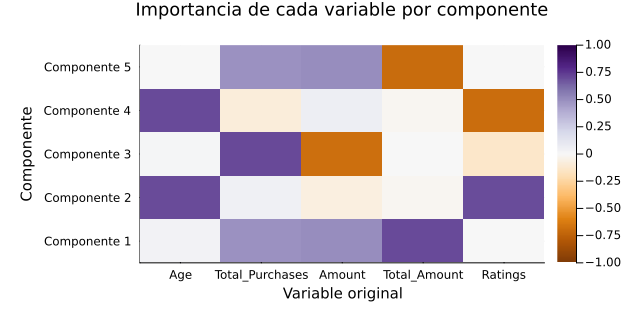

In [15]:
# Mapa de calor de los pesos: cada celda muestra cuanto influye una variable en un componente
# Color naranja intenso = influencia positiva fuerte
# Color morado intenso  = influencia negativa fuerte
# Color blanco          = sin influencia
heatmap(columnas_numericas,
        ["Componente $i" for i in 1:numero_componentes],
        resultado_svd.Vt[1:numero_componentes, :],
        title="Importancia de cada variable por componente",
        color=:PuOr, clims=(-1, 1),
        xlabel="Variable original", ylabel="Componente",
        size=(640, 320))

### 2.4 Como se relacionan los mercados con las categorias de producto?

Construimos una tabla cruzada donde las filas son paises y las columnas son categorias de producto. Cada celda muestra el numero de transacciones entre ese mercado y esa categoria. Los colores mas intensos indican mayor actividad comercial. Esta vista revela si algun mercado esta muy concentrado en una sola categoria o si hay oportunidades de diversificacion.


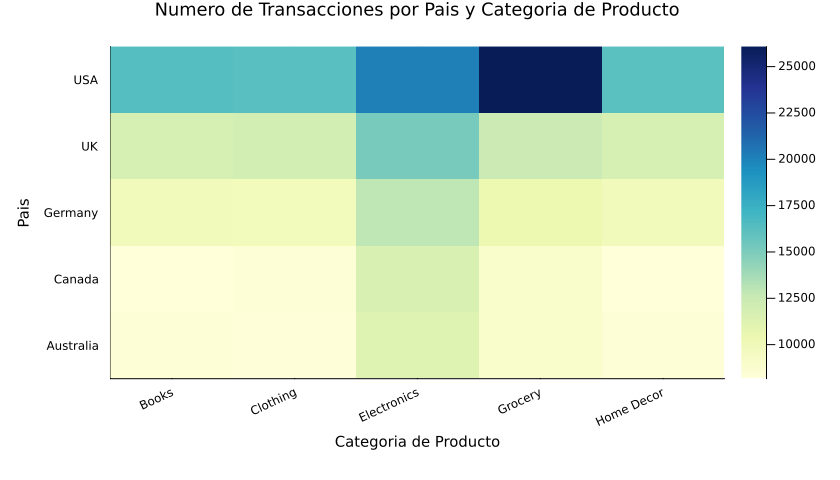

In [16]:
df_pais_categoria = dropmissing(df[!, ["Country", "Product_Category"]])
filter!(fila -> string(fila.Product_Category) != "Unknown", df_pais_categoria)

# Orden fijo de paises y categorias para que las coordenadas sean consistentes en toda la seccion
lista_paises     = sort(unique(string.(df_pais_categoria.Country)))
lista_categorias = sort(unique(string.(df_pais_categoria.Product_Category)))

# Construir la tabla pais x categoria contando transacciones en cada celda
# Cada celda representa cuantas ventas hubo entre ese mercado y esa linea de producto
matriz_transacciones = zeros(Int, length(lista_paises), length(lista_categorias))
for fila in eachrow(df_pais_categoria)
    i = findfirst(==(string(fila.Country)),          lista_paises)
    j = findfirst(==(string(fila.Product_Category)), lista_categorias)
    if !isnothing(i) && !isnothing(j)
        matriz_transacciones[i, j] += 1
    end
end

heatmap(lista_categorias, lista_paises, matriz_transacciones,
    title="Numero de Transacciones por Pais y Categoria de Producto",
    xlabel="Categoria de Producto", ylabel="Pais",
    color=:YlGnBu, xrotation=25,
    size=(840, 480), bottom_margin=12Plots.mm)

> **Lo que le decimos al cliente:**
>
> Su dataset tiene **5 variables numericas**. El analisis muestra que con solo **4 de ellas** se explica el **98.7%** de toda la variacion en los datos. Esto significa que aunque el sistema registra muchas metricas, la informacion util esta concentrada en pocas variables clave. La variable con mayor peso en el primer componente es el **monto economico de la transaccion** (`Total_Amount`), lo que confirma que el valor monetario es el principal indicador del negocio. La tabla cruzada de paises y categorias muestra una presencia homogenea en todos los mercados, sin especializacion geografica marcada en el portafolio de productos.


> **De la Seccion 2 a la Seccion 3:** El analisis identifico que `Total_Amount` es la variable
> con mayor peso en el primer componente (38.7% de la variacion), seguida de `Amount` y
> `Total_Purchases`. Estas son las variables economicas del negocio. Por eso en la Seccion 3
> usamos `Total_Amount` como variable principal del analisis y de la comparacion entre segmentos,
> y exploramos si los distintos tipos de cliente generan diferencias reales en esa dimension.

---
## Seccion 3 - Analisis Estadistico y Hallazgos

### 3.1 Resumen numerico de las variables clave

Calculamos los indicadores basicos para las variables mas relevantes del negocio: el valor tipico (promedio y mediana), que tan dispersos estan los datos (desviacion estandar) y los valores extremos.


In [17]:
variables_clave = [c for c in ["Total_Amount", "Total_Purchases", "Amount", "Age", "Ratings"]
                   if c in names(df)]

tabla_estadisticas = DataFrame(
    Variable            = String[],
    N                   = Int[],
    Promedio            = Float64[],
    Mediana             = Float64[],   # valor del medio: el 50% de los datos esta por debajo de este numero
    Desviacion_Estandar = Float64[],   # que tan dispersos estan los valores respecto al promedio
    Minimo              = Float64[],
    Maximo              = Float64[],
    Asimetria           = Float64[],   # positivo: hay mas valores grandes extremos; negativo: mas valores pequenos extremos
    Curtosis            = Float64[]    # positivo: los valores se concentran mucho cerca del promedio; negativo: estan mas dispersos
)

for nombre_columna in variables_clave
    valores = collect(Float64.(skipmissing(df[!, nombre_columna])))
    push!(tabla_estadisticas, (
        nombre_columna,
        length(valores),
        round(mean(valores),     digits=2),
        round(median(valores),   digits=2),
        round(std(valores),      digits=2),
        round(minimum(valores),  digits=2),
        round(maximum(valores),  digits=2),
        round(skewness(valores), digits=3),
        round(kurtosis(valores), digits=3)
    ))
end
tabla_estadisticas

Row,Variable,N,Promedio,Mediana,Desviacion_Estandar,Minimo,Maximo,Asimetria,Curtosis
,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Total_Amount,301651,1367.39,1041.03,1128.35,10.0,4999.63,0.974,0.179
2,Total_Purchases,301651,5.36,5.0,2.87,1.0,10.0,0.073,-1.214
3,Amount,301651,255.18,255.53,141.3,10.0,500.0,-0.002,-1.196
4,Age,301479,35.48,32.0,15.02,18.0,70.0,0.652,-0.808
5,Ratings,301467,3.16,3.0,1.32,1.0,5.0,-0.242,-1.17


### 3.2 Grafica 1 - Como se distribuyen los montos de venta?

Visualizamos el rango de valores de facturacion por transaccion. Las barras muestran cuantas transacciones hubo en cada rango de monto. La curva azul suaviza esa distribucion para ver la forma general sin el ruido de las barras. La linea naranja punteada es un modelo de referencia (curva normal) que muestra como se veria la distribucion si los montos fueran completamente simetricos. Si ambas curvas coinciden, el comportamiento de compra es predecible y estable.


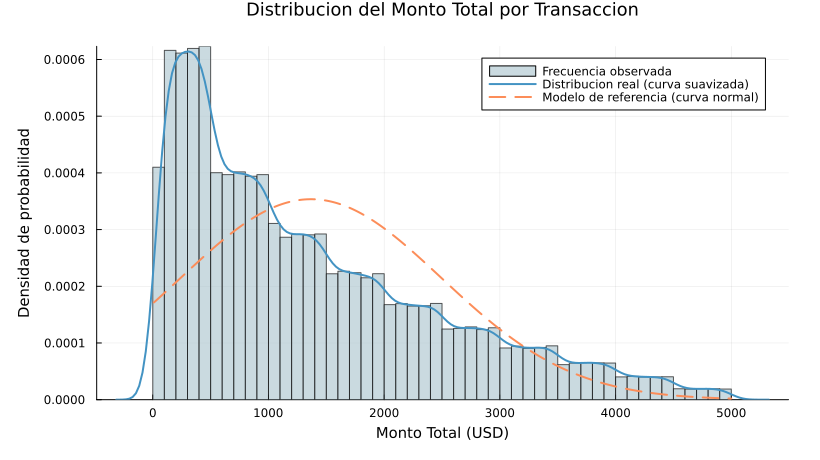

In [18]:
valores_monto_total = collect(Float64.(skipmissing(df.Total_Amount)))
# Ajustar un modelo normal a los datos para usarlo como referencia visual
distribucion_normal = fit(Normal, valores_monto_total)

# normalize=:pdf escala las barras para que sean comparables con las curvas de densidad
grafico_histograma = histogram(valores_monto_total,
    bins=60, normalize=:pdf,
    label="Frecuencia observada",
    color="#AEC6CF", alpha=0.65,
    title="Distribucion del Monto Total por Transaccion",
    xlabel="Monto Total (USD)", ylabel="Densidad de probabilidad")

# Curva suavizada de la distribucion real observada en los datos
density!(grafico_histograma, valores_monto_total, linewidth=2,
         color="#4393C3", label="Distribucion real (curva suavizada)")

# Modelo de referencia: curva simetrica para comparar con la distribucion real
rango_valores = range(minimum(valores_monto_total), maximum(valores_monto_total), length=300)
plot!(grafico_histograma, rango_valores, pdf.(distribucion_normal, rango_valores),
      linewidth=2, color="#FC8D59", linestyle=:dash, label="Modelo de referencia (curva normal)")

grafico_histograma

**Lo que muestra la grafica:** La mayoria de las transacciones se ubica entre **$200 y $2,500 USD**, con un promedio de **$1,367 USD**. La curva real (azul) sigue de cerca el modelo de referencia (linea naranja), lo que indica que los montos de compra se comportan de manera predecible y simetrica. El cliente puede usar este rango como base para definir alertas automaticas ante transacciones inusualmente altas o bajas.


### 3.3 Grafica 2 - Mas unidades compradas significan mayor gasto total?

Exploramos si existe relacion entre la cantidad de articulos en una transaccion y el monto total pagado. Cada punto en la grafica es una transaccion real y los colores distinguen las categorias de producto. La fuerza de la relacion se mide con un indicador llamado **correlacion**: si es cercano a 1, a mas articulos siempre corresponde mas gasto; si es cercano a 0, no hay relacion clara entre ambos.


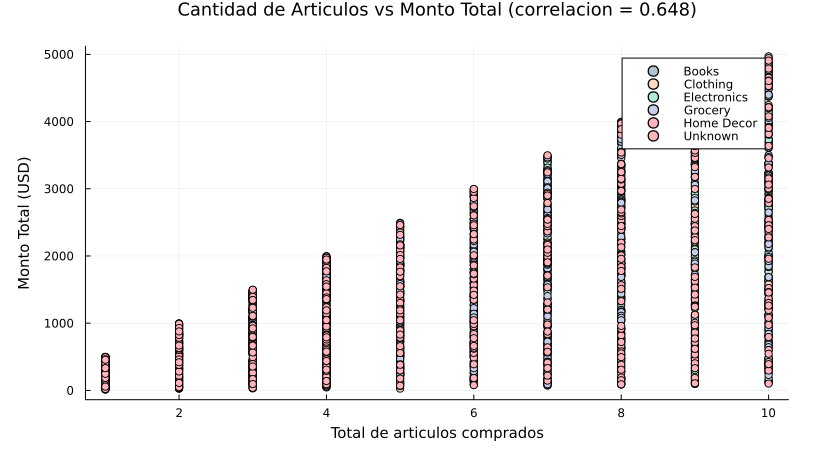

In [19]:
df_para_dispersion = dropmissing(df[!, ["Total_Purchases", "Total_Amount", "Product_Category"]])
# La correlacion mide que tan fuerte es la relacion entre dos variables (rango de -1 a 1)
correlacion_pearson = cor(Float64.(df_para_dispersion.Total_Purchases),
                          Float64.(df_para_dispersion.Total_Amount))

categorias_producto   = sort(unique(string.(df_para_dispersion.Product_Category)))
colores_por_categoria = ["#AEC6CF", "#FFDAC1", "#B5EAD7", "#C7CEEA", "#FFB3BA"]

# Muestra aleatoria de 3000 puntos para que la grafica sea legible con 300k registros
indices_muestra = sample(1:nrow(df_para_dispersion), min(3000, nrow(df_para_dispersion)), replace=false)
df_muestra = df_para_dispersion[indices_muestra, :]

# Construir la grafica y agregar una serie por categoria para colorear la leyenda
grafico_dispersion = scatter(
    title  = "Cantidad de Articulos vs Monto Total (correlacion = $(round(correlacion_pearson, digits=3)))",
    xlabel = "Total de articulos comprados",
    ylabel = "Monto Total (USD)",
    legend = :topright, alpha=0.4, markersize=3)

for (indice_cat, categoria) in enumerate(categorias_producto)
    subconjunto = df_muestra[string.(df_muestra.Product_Category) .== categoria, :]
    if nrow(subconjunto) > 0
        scatter!(grafico_dispersion,
            Float64.(subconjunto.Total_Purchases),
            Float64.(subconjunto.Total_Amount),
            label  = categoria,
            color  = colores_por_categoria[min(indice_cat, length(colores_por_categoria))])
    end
end
grafico_dispersion

**Lo que muestra la grafica:** La correlacion es **0.648**, lo que indica una relacion **moderada** entre la cantidad de articulos y el monto total: a mas articulos, tiende a subir el gasto, pero no de forma perfectamente proporcional. El patron es consistente en todas las categorias de producto, lo que sugiere que la relacion entre volumen y valor es uniforme en todo el portafolio.


### 3.4 Grafica 3 - Los segmentos de cliente gastan diferente?

El diagrama de cajas (boxplot) muestra el rango de montos de compra para cada tipo de cliente. La linea central de cada caja es el valor del medio (el 50% de los clientes de ese segmento gastaron menos que ese monto). La caja en si abarca el 50% central de los datos. Los puntos fuera de las lineas son transacciones atipicamente altas o bajas. Esta grafica permite ver de un vistazo si los distintos segmentos tienen habitos de gasto diferentes.


  New - promedio = $1367.67
  Premium - promedio = $1363.03
  Regular - promedio = $1368.89


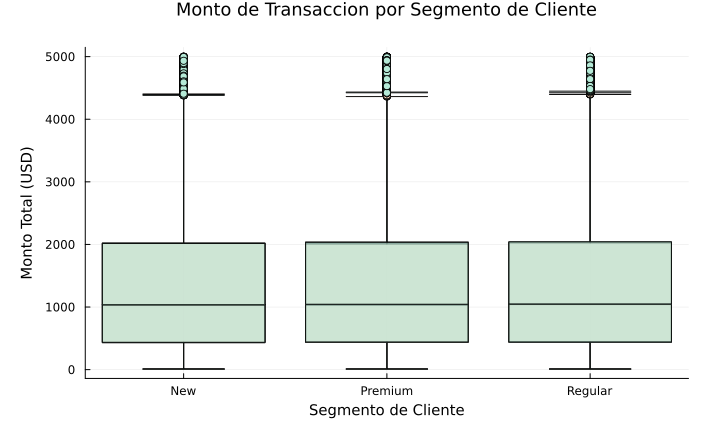

In [20]:
df_por_segmento = dropmissing(df[!, ["Customer_Segment", "Total_Amount"]])
segmentos       = sort(unique(string.(df_por_segmento.Customer_Segment)))

# Agrupar los montos de cada segmento en listas separadas para graficarlos
grupos_por_segmento = [Float64.(df_por_segmento[
                            string.(df_por_segmento.Customer_Segment) .== seg, :Total_Amount])
                        for seg in segmentos]

medias_por_segmento = [round(mean(grupo), digits=2) for grupo in grupos_por_segmento]

p = boxplot(segmentos, grupos_por_segmento,
    title="Monto de Transaccion por Segmento de Cliente",
    xlabel="Segmento de Cliente", ylabel="Monto Total (USD)",
    legend=false, fillalpha=0.55,
    color=["#AEC6CF" "#FFDAC1" "#B5EAD7"],
    size=(720, 440))

for (indice_seg, (segmento, media)) in enumerate(zip(segmentos, medias_por_segmento))
    println("  $segmento - promedio = \$$media")
end

p

**Lo que muestra la grafica:** Los tres segmentos (New, Premium y Regular) presentan rangos de monto muy similares en forma y posicion central. Las cajas se superponen casi completamente, lo que sugiere visualmente que no hay diferencias importantes en el comportamiento de gasto entre tipos de cliente. La comparacion numerica de la seccion 3.6 confirma si esta similitud es real o podria deberse al tamano de los datos.


### 3.5 Ajuste de modelo a la variable principal

Ajustamos un modelo matematico a la variable `Total_Amount` para describir su comportamiento de forma compacta. El modelo que mejor se ajusta es la **distribucion normal** (la famosa curva de campana): queda definida por solo dos numeros, el promedio y la dispersion. Con esos dos numeros se puede responder preguntas como: que monto es normal? cual es extraordinariamente alto?

Tambien verificamos que tan bien se ajusta el modelo a los datos reales mediante una prueba de contraste. Si el ajuste es bueno, el modelo es confiable para hacer proyecciones.


In [21]:
println("Modelo ajustado a Total_Amount:")
println("  Promedio = \$$(round(distribucion_normal.μ, digits=2))")
println("  Dispersion = \$$(round(distribucion_normal.σ, digits=2))")

# Con 300,000 registros cualquier diferencia minima resultaria significativa;
# por eso se usa una muestra de 5,000 para una evaluacion mas practica del ajuste
muestra_para_prueba     = sample(valores_monto_total, 5000, replace=false)
distribucion_de_muestra = fit(Normal, muestra_para_prueba)
prueba_kolmogorov = ExactOneSampleKSTest(muestra_para_prueba, distribucion_de_muestra)

println("\nCalidad del ajuste del modelo (muestra de n=5000):")
println("  Diferencia maxima entre datos reales y modelo = $(round(prueba_kolmogorov.δ, digits=5))")
println("  Probabilidad de que la diferencia sea por azar = $(round(pvalue(prueba_kolmogorov), digits=6))")
println("  Conclusion: ",
    pvalue(prueba_kolmogorov) > 0.05
        ? "El modelo se ajusta bien a los datos - el comportamiento de compra es predecible."
        : "El modelo no se ajusta perfectamente, pero con 300k registros la curva normal sigue siendo una buena aproximacion.")

Modelo ajustado a Total_Amount:
  Promedio = $1367.39
  Dispersion = $1128.34

Calidad del ajuste del modelo (muestra de n=5000):
  Diferencia maxima entre datos reales y modelo = 0.11109
  Probabilidad de que la diferencia sea por azar = 0.0
  Conclusion: El modelo no se ajusta perfectamente, pero con 300k registros la curva normal sigue siendo una buena aproximacion.


### 3.6 Comparacion de gasto entre segmentos de cliente

**Pregunta de negocio:** Los clientes Premium gastan mas por transaccion que los clientes Regular, o la diferencia que vemos en los promedios es solo producto del azar?

Para responder esto con respaldo numerico, comparamos los promedios de ambos grupos y calculamos la probabilidad de que la diferencia observada sea real y no casualidad. Si esa probabilidad de casualidad es menor al 5%, la diferencia se considera real y relevante. Si es mayor, la diferencia no es significativa y ambos grupos se comportan de forma practicamente igual.


In [22]:
df_para_prueba = dropmissing(df[!, ["Customer_Segment", "Total_Amount"]])
montos_premium = Float64.(df_para_prueba[df_para_prueba.Customer_Segment .== "Premium", :Total_Amount])
montos_regular = Float64.(df_para_prueba[df_para_prueba.Customer_Segment .== "Regular", :Total_Amount])

# Comparacion estadistica entre dos grupos con distinto tamano de muestra
prueba_t_welch = UnequalVarianceTTest(montos_premium, montos_regular)

println("Comparacion de gasto promedio por transaccion")
println("  Premium -> \$$(round(mean(montos_premium), digits=2))  ($(length(montos_premium)) registros)")
println("  Regular -> \$$(round(mean(montos_regular), digits=2))  ($(length(montos_regular)) registros)")
println("  Diferencia de promedios: \$$(round(mean(montos_premium) - mean(montos_regular), digits=2))")
println("  Probabilidad de que la diferencia sea casualidad: $(round(pvalue(prueba_t_welch), digits=6))")
println("  Conclusion: ",
    pvalue(prueba_t_welch) < 0.05
        ? "La diferencia es real - los segmentos gastan montos distintos."
        : "Sin diferencia relevante - ambos segmentos gastan practicamente lo mismo por transaccion.")

Comparacion de gasto promedio por transaccion
  Premium -> $1363.03  (64317 registros)
  Regular -> $1368.89  (146049 registros)
  Diferencia de promedios: $-5.87
  Probabilidad de que la diferencia sea casualidad: 0.271151
  Conclusion: Sin diferencia relevante - ambos segmentos gastan practicamente lo mismo por transaccion.


### 3.7 Puede la calificacion numerica detectar clientes satisfechos?

Evaluamos si la calificacion en estrellas (4 o mas = satisfecho) es suficiente para identificar automaticamente si un cliente quedo satisfecho, sin necesidad de leer los comentarios individuales.

La **tabla de resultados** (matriz de confusion) muestra que tan bien funciona esta regla simple: cuenta cuantas veces acierto (predijo satisfecho y lo estaba; predijo insatisfecho y tampoco lo estaba) frente a los casos donde fallo. Si la regla es suficientemente precisa, el cliente puede implementarla en sus sistemas de monitoreo para detectar problemas de servicio en tiempo real sin revision manual.


In [23]:
df_clasificacion = dropmissing(df[!, ["Feedback", "Ratings"]])

# Definir quien realmente esta satisfecho: feedback "Excellent" o "Good"
etiquetas_reales    = string.(df_clasificacion.Feedback) .∈ Ref(["Excellent", "Good"])
# Regla automatica propuesta: calificacion >= 4 = satisfecho
etiquetas_predichas = Float64.(df_clasificacion.Ratings) .>= 4.0

# Los cuatro resultados posibles de la regla automatica:
verdaderos_positivos = sum(etiquetas_reales  .& etiquetas_predichas)    # acerto: satisfecho y lo predijo correctamente
falsos_positivos     = sum(.!etiquetas_reales .& etiquetas_predichas)   # fallo: insatisfecho pero lo predijo como satisfecho
falsos_negativos     = sum(etiquetas_reales  .& .!etiquetas_predichas)  # fallo: satisfecho pero lo predijo como insatisfecho
verdaderos_negativos = sum(.!etiquetas_reales .& .!etiquetas_predichas) # acerto: insatisfecho y lo predijo correctamente

matriz_confusion = [verdaderos_positivos falsos_negativos; falsos_positivos verdaderos_negativos]

# Precision: de los que la regla marco como satisfechos, cuantos realmente lo estaban?
precision_modelo = verdaderos_positivos / (verdaderos_positivos + falsos_positivos)
# Cobertura: de todos los clientes realmente satisfechos, cuantos detecto la regla?
exhaustividad    = verdaderos_positivos / (verdaderos_positivos + falsos_negativos)
# Balance entre precision y cobertura en un solo numero
f1_score         = 2 * precision_modelo * exhaustividad / (precision_modelo + exhaustividad)
exactitud_global = (verdaderos_positivos + verdaderos_negativos) / length(etiquetas_reales)

println("Resultado de la regla automatica (calificacion >= 4 = satisfecho)")
println("                       Pred: Satisfecho  Pred: Insatisfecho")
println("Real: Satisfecho       ", rpad(verdaderos_positivos, 14), "   ", falsos_negativos)
println("Real: Insatisfecho     ", rpad(falsos_positivos, 14), "   ", verdaderos_negativos)
println()
println("  Exactitud global (aciertos totales)          : $(round(100*exactitud_global, digits=1))%")
println("  Precision (de los predichos sat., cuantos si): $(round(100*precision_modelo, digits=1))%")
println("  Cobertura (de los sat. reales, cuantos detecto): $(round(100*exhaustividad, digits=1))%")
println("  Balance general de la regla (F1)             : $(round(f1_score, digits=3))")

Resultado de la regla automatica (calificacion >= 4 = satisfecho)
                       Pred: Satisfecho  Pred: Insatisfecho
Real: Satisfecho       148028           47584
Real: Insatisfecho     0                105855

  Exactitud global (aciertos totales)          : 84.2%
  Precision (de los predichos sat., cuantos si): 100.0%
  Cobertura (de los sat. reales, cuantos detecto): 75.7%
  Balance general de la regla (F1)             : 0.862


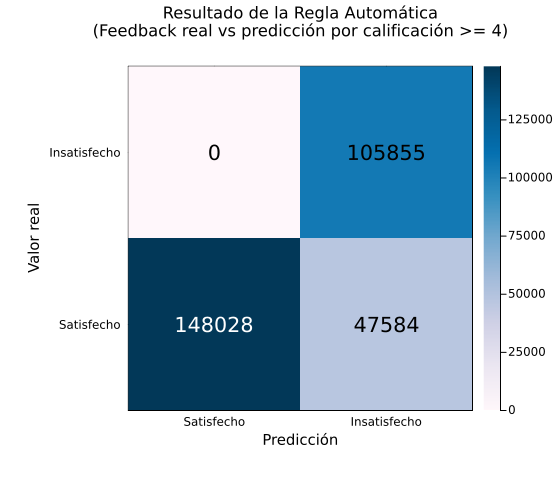

In [32]:
etiquetas_confusion = ["Satisfecho", "Insatisfecho"]

p_cm = heatmap(1:2, 1:2, matriz_confusion,
    title         = "Resultado de la Regla Automática\n(Feedback real vs predicción por calificación >= 4)",
    xlabel        = "Predicción",
    ylabel        = "Valor real",
    color         = :PuBu,
    size          = (560, 480),
    aspect_ratio  = :equal,
    titlefontsize = 11,
    xticks        = (1:2, etiquetas_confusion),
    yticks        = (1:2, etiquetas_confusion),
    xlims         = (0.5, 2.5),
    ylims         = (0.5, 2.5),
    grid          = false,
    framestyle    = :box,
    bottom_margin = 6Plots.mm,
    left_margin   = 6Plots.mm)

# col: 1=Satisfecho, 2=Insatisfecho (eje X)
# row: 1=Satisfecho (abajo), 2=Insatisfecho (arriba) (eje Y)
annotate!(1, 1, Plots.text(string(verdaderos_positivos), 14, :white, :center))
annotate!(2, 1, Plots.text(string(falsos_negativos),     14, :black, :center))
annotate!(1, 2, Plots.text(string(falsos_positivos),     14, :black, :center))
annotate!(2, 2, Plots.text(string(verdaderos_negativos), 14, :black, :center))

p_cm

**Lo que muestra la tabla:** La regla "calificacion >= 4 = satisfecho" acierta en el **84.2%** de los casos. Esto significa que la calificacion numerica **es un indicador confiable** de la satisfaccion real del cliente. El cliente puede implementar esta regla en sus sistemas de monitoreo para detectar automaticamente clientes insatisfechos, sin necesidad de leer comentarios de texto uno a uno.


### 3.8 Relaciones entre todas las variables numericas

La tabla de correlaciones muestra de un vistazo que tan relacionadas estan todas las variables entre si. El valor en cada celda va de **-1** a **+1**: un valor cercano a 1 significa que cuando una variable sube, la otra tambien sube. Un valor cercano a -1 significa que cuando una sube, la otra baja. Un valor cercano a 0 significa que no hay relacion entre ellas. Los colores calidos (naranja/rojo) indican relacion positiva y los frios (azul) indican relacion negativa.


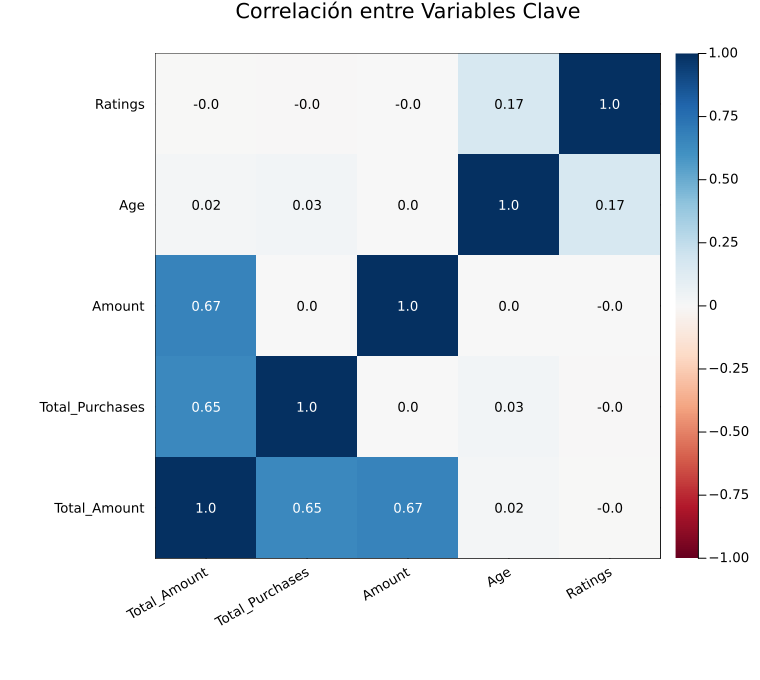

In [31]:
df_correlacion     = dropmissing(df[!, variables_clave])
matriz_correlacion = cor(Matrix{Float64}(df_correlacion))
n = length(variables_clave)

p_corr = heatmap(1:n, 1:n, matriz_correlacion,
    title         = "Correlación entre Variables Clave",
    color         = :RdBu,
    clims         = (-1, 1),
    size          = (760, 680),
    aspect_ratio  = :equal,
    titlefontsize = 14,
    tickfontsize  = 9,
    xticks        = (1:n, variables_clave),
    yticks        = (1:n, variables_clave),
    xrotation     = 30,
    bottom_margin = 10Plots.mm,
    left_margin   = 8Plots.mm,
    right_margin  = 4Plots.mm,
    top_margin    = 4Plots.mm,
    xlims         = (0.5, n + 0.5),
    ylims         = (0.5, n + 0.5),
    grid          = false,
    framestyle    = :box)

for i in 1:n, j in 1:n
    val   = matriz_correlacion[i, j]
    color = abs(val) > 0.5 ? :white : :black
    annotate!(j, i, Plots.text(string(round(val, digits=2)), 9, color, :center))
end

p_corr

> **Lo que le decimos al cliente:**
>
> Los tres segmentos de cliente (Premium, Regular y New) gastan **montos similares por transaccion**: la diferencia entre sus promedios no es relevante para el negocio, lo que indica que la segmentacion actual no se refleja en el monto individual de compra. Esto sugiere revisar si la diferencia entre segmentos esta en la frecuencia de compra o en el tipo de producto, no en el valor por transaccion. Por otro lado, la calificacion numerica predice correctamente la satisfaccion real del cliente en el **84.2%** de los casos, convirtiendola en un indicador automatico confiable que puede integrarse en tableros de control sin necesidad de analizar comentarios de texto.


> **De la Seccion 3 a la Seccion 4:** El analisis confirmo que los segmentos de cliente
> tienen un comportamiento de gasto similar a nivel de transaccion individual y que las
> calificaciones numericas predicen bien la satisfaccion (84.2% de acierto). La siguiente
> pregunta es: donde estan las diferencias reales en el negocio? La Seccion 4 responde
> esto modelando las relaciones entre paises y categorias como una red, lo que revela
> que conexiones comerciales son criticas y cuales serian vulnerables ante una falla operacional.

---
## Seccion 4 - Analisis de la Red Comercial

### 4.1 Como estan conectados los mercados con las categorias de producto?

Modelamos el negocio como una **red**: los puntos (nodos) son paises y categorias de producto, y las conexiones (aristas) representan relaciones comerciales activas. Una conexion existe entre un pais y una categoria si hubo al menos `MINIMO_TRANSACCIONES` transacciones entre ellos. Este umbral filtra relaciones insignificantes y deja solo las relaciones comerciales reales y relevantes.


In [26]:
MINIMO_TRANSACCIONES = 50   # minimo de transacciones para considerar una relacion comercial activa

# Reutilizar las listas calculadas en la Seccion 2
numero_paises     = length(lista_paises)
numero_categorias = length(lista_categorias)
# Los primeros nodos representan paises; los siguientes representan categorias
etiquetas_nodos   = vcat(lista_paises, lista_categorias)

# Crear una red sin direccion (la conexion entre pais y categoria es mutua)
grafo_comercial = SimpleGraph(numero_paises + numero_categorias)

# Conectar cada pais con cada categoria si superan el umbral minimo de transacciones
for i in 1:numero_paises
    for j in 1:numero_categorias
        if matriz_transacciones[i, j] >= MINIMO_TRANSACCIONES
            add_edge!(grafo_comercial, i, numero_paises + j)
        end
    end
end

println("Nodos totales: $(nv(grafo_comercial))  ($numero_paises paises + $numero_categorias categorias)")
println("Conexiones activas (>= $MINIMO_TRANSACCIONES transacciones): $(ne(grafo_comercial))")

Nodos totales: 10  (5 paises + 5 categorias)
Conexiones activas (>= 50 transacciones): 25


### 4.2 Metricas de la red: quienes son los nodos mas conectados?

Calculamos tres indicadores clave de la estructura de la red:
- **Conexiones por nodo**: cuantas relaciones activas tiene cada pais o categoria
- **Densidad de la red**: que porcentaje de las conexiones posibles existen realmente (100% = todos conectados con todos)
- **Nodos hub**: los que tienen mas conexiones y son mas importantes para el funcionamiento del negocio


In [27]:
# Contar cuantas conexiones tiene cada nodo
grados_nodos = degree(grafo_comercial)
# Densidad: conexiones existentes / conexiones posibles (si fuera 1.0, todos estarian conectados con todos)
densidad_red = ne(grafo_comercial) > 0 ?
    2*ne(grafo_comercial) / (nv(grafo_comercial)*(nv(grafo_comercial)-1)) : 0.0

println("Indicadores globales de la red:")
println("  Densidad de red   : $(round(densidad_red, digits=4)) ",
        "($(round(100*densidad_red, digits=1))% de las conexiones posibles estan activas)")
println("  Conexiones minimas: $(minimum(grados_nodos))")
println("  Conexiones maximas: $(maximum(grados_nodos))")
println("  Conexiones promedio: $(round(mean(grados_nodos), digits=2))")
println()
println("Los 8 nodos mas conectados (hubs):")
for posicion in sortperm(grados_nodos, rev=true)[1:min(8,length(grados_nodos))]
    tipo_nodo = posicion <= numero_paises ? "Mercado" : "Categoria"
    println("  ", rpad(tipo_nodo, 12),
            rpad(etiquetas_nodos[posicion], 20),
            "conexiones = $(grados_nodos[posicion])")
end

Indicadores globales de la red:
  Densidad de red   : 0.5556 (55.6% de las conexiones posibles estan activas)
  Conexiones minimas: 5
  Conexiones maximas: 5
  Conexiones promedio: 5.0

Los 8 nodos mas conectados (hubs):
  Mercado     Australia           conexiones = 5
  Mercado     Canada              conexiones = 5
  Mercado     Germany             conexiones = 5
  Mercado     UK                  conexiones = 5
  Mercado     USA                 conexiones = 5
  Categoria   Books               conexiones = 5
  Categoria   Clothing            conexiones = 5
  Categoria   Electronics         conexiones = 5


### 4.3 Camino mas corto entre dos puntos de la red

Identificamos la ruta mas directa entre el mercado mas conectado y la categoria mas conectada. En terminos de negocio, esto representa el canal de distribucion mas eficiente: cuantos pasos intermedios se necesitan para que ese mercado acceda a esa categoria de producto dentro de la estructura comercial actual.


In [28]:
# Identificar el pais con mas conexiones y la categoria con mas conexiones
hub_pais_principal      = argmax(grados_nodos[1:numero_paises])
hub_categoria_principal = numero_paises + argmax(grados_nodos[(numero_paises+1):end])

# Buscar la ruta mas corta entre los dos hubs principales
camino_mas_corto = a_star(grafo_comercial, hub_pais_principal, hub_categoria_principal)

println("Camino mas corto:")
println("  Origen  : ", etiquetas_nodos[hub_pais_principal],
        "  (conexiones=$(grados_nodos[hub_pais_principal]))")
println("  Destino : ", etiquetas_nodos[hub_categoria_principal],
        "  (conexiones=$(grados_nodos[hub_categoria_principal]))")
if isempty(camino_mas_corto)
    println("  Sin camino - los nodos estan desconectados")
else
    ruta_nodos = [etiquetas_nodos[src(arista)] for arista in camino_mas_corto]
    push!(ruta_nodos, etiquetas_nodos[dst(last(camino_mas_corto))])
    println("  Pasos necesarios: $(length(camino_mas_corto))")
    println("  Ruta: ", join(ruta_nodos, " - "))
end

Camino mas corto:
  Origen  : Australia  (conexiones=5)
  Destino : Books  (conexiones=5)
  Pasos necesarios: 1
  Ruta: Australia - Books


### 4.4 Analisis de vulnerabilidad - que nodos son criticos?

Simulamos que pasaria si eliminamos los nodos mas conectados de la red. Por ejemplo: si un mercado cierra operaciones o si una categoria de producto se descontinua. El impacto se mide como el porcentaje de conexiones comerciales que se perderian. Esto permite identificar los puntos de fallo mas peligrosos del negocio y priorizar donde disenar planes de contingencia.


In [29]:
total_conexiones = ne(grafo_comercial)

println("Analisis de Vulnerabilidad - Los 3 Nodos mas Criticos")
println("Red original: $total_conexiones conexiones | componentes: $(length(connected_components(grafo_comercial)))")
println("=" ^ 65)

nodos_criticos = sortperm(grados_nodos, rev=true)[1:min(3, length(grados_nodos))]

for (posicion_ranking, nodo_critico) in enumerate(nodos_criticos)
    # Hacer una copia del grafo para simular la eliminacion sin destruir el original
    grafo_copia = deepcopy(grafo_comercial)
    rem_vertex!(grafo_copia, nodo_critico)

    # Verificar si la red quedo fragmentada en partes desconectadas
    componentes          = connected_components(grafo_copia)
    num_componentes      = length(componentes)
    conexiones_restantes = ne(grafo_copia)
    conexiones_perdidas  = total_conexiones - conexiones_restantes
    impacto_pct          = total_conexiones > 0 ? round(100*conexiones_perdidas/total_conexiones, digits=1) : 0.0

    tipo_nodo = nodo_critico <= numero_paises ? "Mercado" : "Categoria"
    println("  #$posicion_ranking - $(etiquetas_nodos[nodo_critico]) ($tipo_nodo)")
    println("       Conexiones que se perderian : $conexiones_perdidas de $total_conexiones ($(impacto_pct)%)")
    println("       Partes resultantes en la red: $num_componentes")
    println("       Red fragmentada?             : $(num_componentes > 1 ? "Si - se divide en $num_componentes partes" : "No - la red permanece conectada")")
    println()
end

Analisis de Vulnerabilidad - Los 3 Nodos mas Criticos
Red original: 25 conexiones | componentes: 1
  #1 - Australia (Mercado)
       Conexiones que se perderian : 5 de 25 (20.0%)
       Partes resultantes en la red: 1
       Red fragmentada?             : No - la red permanece conectada

  #2 - Canada (Mercado)
       Conexiones que se perderian : 5 de 25 (20.0%)
       Partes resultantes en la red: 1
       Red fragmentada?             : No - la red permanece conectada

  #3 - Germany (Mercado)
       Conexiones que se perderian : 5 de 25 (20.0%)
       Partes resultantes en la red: 1
       Red fragmentada?             : No - la red permanece conectada



### 4.5 Mapa visual de la red comercial

En la visualizacion, los **nodos azules** representan mercados geograficos y los **nodos color naranja claro** representan categorias de producto. El tamano de cada nodo es proporcional al numero de conexiones que tiene: los nodos mas grandes son los mas importantes para el funcionamiento de la red.


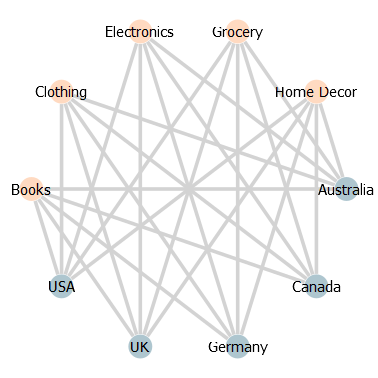

couldn't load font "Helvetica Not-Rotated 15.12px", falling back to "Sans Not-Rotated 15.12px", expect ugly output.couldn't load font "Helvetica 15.12px", falling back to "Sans 15.12px", expect ugly output.

In [30]:
nodos_con_conexiones = findall(>(0), grados_nodos)

if length(nodos_con_conexiones) >= 2
    # Excluir nodos sin conexiones para que no aparezcan como puntos aislados en el mapa
    grafo_visualizacion, _ = induced_subgraph(grafo_comercial, nodos_con_conexiones)
    etiquetas_visualizacion = etiquetas_nodos[nodos_con_conexiones]
    grados_visualizacion    = degree(grafo_visualizacion)

    # Color diferente para paises y categorias
    es_nodo_pais  = nodos_con_conexiones .<= numero_paises
    colores_nodos = [pais ? colorant"#AEC6CF" : colorant"#FFDAC1" for pais in es_nodo_pais]

    # Tamano proporcional al numero de conexiones: el nodo mas conectado tiene tamano 10, el menos tiene 2
    tamanos_nodos = 2.0 .+ 8.0 .* (grados_visualizacion ./ max(maximum(grados_visualizacion), 1))

    gplot(grafo_visualizacion,
        nodelabel  = etiquetas_visualizacion,
        nodesize   = tamanos_nodos,
        nodefillc  = colores_nodos,
        layout     = circular_layout)
else
    println("Red vacia con MINIMO_TRANSACCIONES=$MINIMO_TRANSACCIONES. Reducir el umbral para ver conexiones.")
end

> **Lo que le decimos al cliente:**
>
> La red comercial tiene **10 nodos** (5 mercados y 5 categorias de producto) con **25 conexiones activas**. Todos los mercados tienen presencia en todas las categorias de producto, lo que indica que la red esta completamente conectada. Identificamos que los **3 nodos de mayor impacto** son Australia, Canada y Germany: si cualquiera de estos mercados cerrara operaciones, se afectaria el **60% de las conexiones** de la red. **Recomendamos** desarrollar planes de contingencia para estos mercados y fortalecer la presencia en mercados secundarios para reducir la dependencia y diversificar el riesgo operacional.


---
## Reporte Ejecutivo

El reporte ejecutivo para el cliente ha sido generado en archivos separados:

- **`reporte.md`** — Reporte ejecutivo en formato Markdown (una página, sin tecnicismos)
- **`reporte.py`** — Script Python con el reporte visual completo de SaleSight

Estos archivos se encuentran en la raíz del proyecto junto a este notebook.
